# Website Traffic Forecasting with Google TimesFM

This notebook implements an end-to-end **hourly website traffic forecasting** workflow for a SaaS/technology platform.

## Problem

Large websites experience seasonal and sudden traffic spikes. Infrastructure teams must scale capacity before demand increases.

## Input

- `Timestamp`
- `Visitors` (here: aggregated web-request traffic from real server logs)

## Forecast Goal

Predict future hourly traffic to:

- auto-scale servers
- reduce latency
- avoid downtime


## What You Will Learn

1. Download a real web-log dataset directly from the web.
2. Transform minute-level logs into hourly traffic.
3. Run data quality checks and build a regular hourly series.
4. Configure and run TimesFM with hourly calendar covariates.
5. Benchmark against baselines (`naive_last`, `seasonal24`, `seasonal168`).
6. Convert forecasts into autoscaling, latency-risk, and downtime-risk plans.


In [1]:
from __future__ import annotations

import math
import os
import subprocess
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Stable CPU behavior across environments.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '')
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'website_traffic'
RAW_DIR = DATA_DIR / 'raw'
ART_DIR = PROJECT_ROOT / 'artifacts' / 'website_traffic_timesfm'

RAW_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / 'NASA Dataset for LSTM.csv'

print('Project root:', PROJECT_ROOT)
print('CSV path:', CSV_PATH)
print('Artifacts dir:', ART_DIR)

Project root: /home/ahmad/AI/Github/google-TimesFM-implementation
CSV path: /home/ahmad/AI/Github/google-TimesFM-implementation/data/website_traffic/raw/NASA Dataset for LSTM.csv
Artifacts dir: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm


## 1) Data Download (Web)

Dataset source (Kaggle):

- `pasanbhanuguruge/nasa-http-logs-dataset-processed-for-lstm-models`

Why this dataset is useful:

- Built from real NASA web server logs.
- Minute-level web traffic counts, easily aggregatable to hourly visitors/traffic.
- Suitable for short-term infrastructure forecasting and capacity planning.


In [2]:
def ensure_dataset(csv_path: Path) -> Path:
    if csv_path.exists():
        print(f'Found existing file: {csv_path}')
        return csv_path

    zip_path = RAW_DIR / 'nasa-http-logs-dataset-processed-for-lstm-models.zip'
    cmd = [
        'kaggle',
        'datasets',
        'download',
        '-d',
        'pasanbhanuguruge/nasa-http-logs-dataset-processed-for-lstm-models',
        '-p',
        str(RAW_DIR),
        '--force',
    ]

    try:
        print('Downloading dataset from Kaggle...')
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except Exception as exc:
        raise RuntimeError(
            'Failed to download dataset from Kaggle. Configure Kaggle API credentials or place '
            f'NASA Dataset for LSTM.csv at {csv_path}.'
        ) from exc

    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(RAW_DIR)

    if not csv_path.exists():
        raise FileNotFoundError(f'Expected file not found after download: {csv_path}')

    return csv_path


csv_path = ensure_dataset(CSV_PATH)
csv_path

Found existing file: /home/ahmad/AI/Github/google-TimesFM-implementation/data/website_traffic/raw/NASA Dataset for LSTM.csv


PosixPath('/home/ahmad/AI/Github/google-TimesFM-implementation/data/website_traffic/raw/NASA Dataset for LSTM.csv')

## 2) Load and Build Hourly Traffic Series

Raw file fields:

- `minute`: minute timestamp
- `count`: request count per minute

Pipeline:

1. Parse timestamps and numeric counts.
2. Build regular minute grid and fill missing minutes with zero.
3. Aggregate to hourly visitors/traffic (`sum`).


In [3]:
raw_df = pd.read_csv(csv_path)

raw_df['minute'] = pd.to_datetime(raw_df['minute'], errors='coerce')
raw_df['count'] = pd.to_numeric(raw_df['count'], errors='coerce')

print('Raw shape:', raw_df.shape)
print('Null minute rows:', int(raw_df['minute'].isna().sum()))
print('Null count rows:', int(raw_df['count'].isna().sum()))
print('Duplicate minute rows:', int(raw_df['minute'].duplicated().sum()))

raw_df = raw_df.dropna(subset=['minute', 'count']).copy()
raw_df = raw_df.sort_values('minute')

# Build strict minute-level grid first for quality control.
minute_series = (
    raw_df.set_index('minute')['count']
    .resample('min').sum()
    .fillna(0.0)
)

hourly_series = minute_series.resample('h').sum().rename('visitors').to_frame().reset_index()
hourly_series = hourly_series.rename(columns={'minute': 'timestamp'})
hourly_series['visitors'] = hourly_series['visitors'].astype(np.float32)

print('Hourly shape:', hourly_series.shape)
print('Hourly range:', hourly_series['timestamp'].min(), '->', hourly_series['timestamp'].max())
print('Hourly mean / max:', float(hourly_series['visitors'].mean()), float(hourly_series['visitors'].max()))

hourly_series.head()

Raw shape: (81396, 2)
Null minute rows: 0
Null count rows: 0
Duplicate minute rows: 0
Hourly shape: (1488, 2)
Hourly range: 1995-07-01 00:00:00 -> 1995-08-31 23:00:00
Hourly mean / max: 2326.35205078125 14926.0


,timestamp,visitors
0,1995-07-01 00:00:00,3565.0
1,1995-07-01 01:00:00,3004.0
2,1995-07-01 02:00:00,2268.0
3,1995-07-01 03:00:00,1734.0
4,1995-07-01 04:00:00,1482.0


In [4]:
# Ensure strict hourly regularity.
full_hours = pd.date_range(hourly_series['timestamp'].min(), hourly_series['timestamp'].max(), freq='h')
series_df = (
    hourly_series.set_index('timestamp')['visitors']
    .reindex(full_hours)
    .fillna(0.0)
    .rename_axis('timestamp')
    .to_frame()
    .reset_index()
)
series_df['visitors'] = series_df['visitors'].astype(np.float32)

print('Regularized series length:', len(series_df))
print('Any missing:', bool(series_df['visitors'].isna().any()))
series_df.head()

Regularized series length: 1488
Any missing: False


,timestamp,visitors
0,1995-07-01 00:00:00,3565.0
1,1995-07-01 01:00:00,3004.0
2,1995-07-01 02:00:00,2268.0
3,1995-07-01 03:00:00,1734.0
4,1995-07-01 04:00:00,1482.0


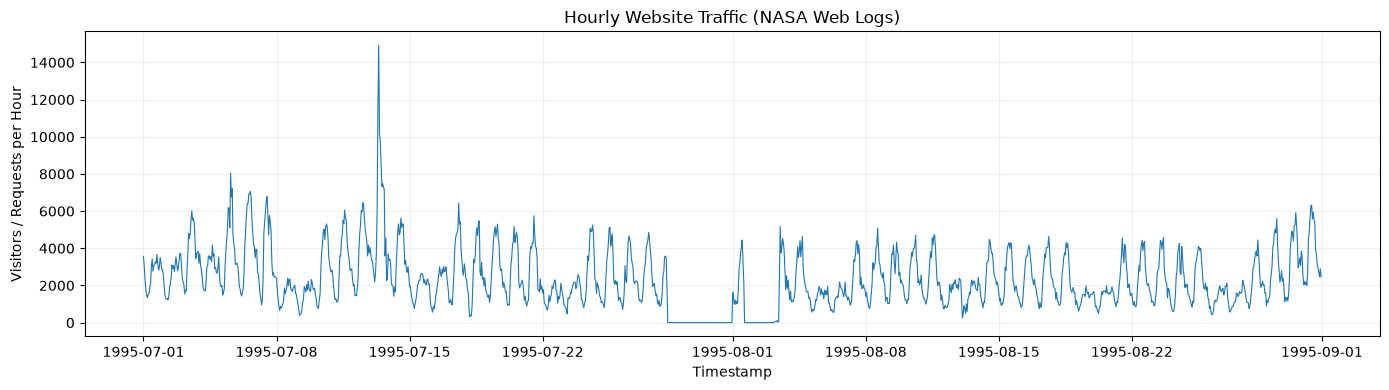

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_df['timestamp'], series_df['visitors'], lw=0.8)
ax.set_title('Hourly Website Traffic (NASA Web Logs)')
ax.set_ylabel('Visitors / Requests per Hour')
ax.set_xlabel('Timestamp')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3) Forecast Configuration

We evaluate:

- next hour (`h=1`)
- next day (`h=24`)
- next week (`h=168`)

Configuration:

- `context_len = 672` (last 4 weeks hourly)
- `max_horizon = 168` (1 week)
- rolling anchors to prevent leakage


In [6]:
@dataclass
class Config:
    context_len: int = 672
    max_horizon: int = 168
    eval_horizons: tuple[int, ...] = (1, 24, 168)
    anchors_weeks_ago: tuple[int, ...] = (6, 4, 2, 1)
    per_core_batch_size: int = 8
    xreg_mode: str = 'xreg + timesfm'
    xreg_ridge: float = 1e-3


cfg = Config()
arr = series_df['visitors'].to_numpy(np.float32)

anchor_positions: list[int] = []
last_pos = len(arr) - 1
for weeks_ago in cfg.anchors_weeks_ago:
    end_pos = last_pos - weeks_ago * 168
    if end_pos - cfg.context_len + 1 >= 0 and end_pos + cfg.max_horizon < len(arr):
        anchor_positions.append(end_pos)

if not anchor_positions:
    raise RuntimeError('No valid anchors found. Reduce context/horizon or provide longer history.')

print('Valid anchors:', len(anchor_positions))
for pos in anchor_positions:
    print(' -', series_df['timestamp'].iloc[pos])

Valid anchors: 3
 - 1995-08-03 23:00:00
 - 1995-08-17 23:00:00
 - 1995-08-24 23:00:00


## 4) Load TimesFM + Covariate Helpers

Dynamic covariates:

- hour-of-day (`sin/cos`)
- day-of-week (`sin/cos`)
- weekend indicator


In [7]:
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
forecast_config = timesfm.ForecastConfig(
    max_context=cfg.context_len,
    max_horizon=cfg.max_horizon,
    normalize_inputs=True,
    per_core_batch_size=cfg.per_core_batch_size,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
)
model.compile(forecast_config)
print('TimesFM compiled.')

TimesFM compiled.


In [8]:
def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8))


def build_dynamic_covariates(start_ts: pd.Timestamp, context_len: int, horizon: int) -> dict[str, list[list[float]]]:
    full_idx = pd.date_range(start_ts, periods=context_len + horizon, freq='h')
    hour = full_idx.hour.values.astype(np.float32)
    dow = full_idx.dayofweek.values.astype(np.float32)

    return {
        'hour_sin': [np.sin(2 * np.pi * hour / 24.0).astype(np.float32).tolist()],
        'hour_cos': [np.cos(2 * np.pi * hour / 24.0).astype(np.float32).tolist()],
        'dow_sin': [np.sin(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'dow_cos': [np.cos(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'is_weekend': [(dow >= 5).astype(np.float32).tolist()],
    }


def run_timesfm_forecast(context: np.ndarray, start_ts: pd.Timestamp, horizon: int) -> tuple[np.ndarray, np.ndarray]:
    cov = build_dynamic_covariates(start_ts, len(context), horizon)

    try:
        point, quant = model.forecast_with_covariates(
            inputs=[context.astype(np.float32)],
            dynamic_numerical_covariates=cov,
            xreg_mode=cfg.xreg_mode,
            ridge=cfg.xreg_ridge,
        )
    except Exception:
        point, quant = model.forecast(horizon=horizon, inputs=[context.astype(np.float32)])

    point_np = np.asarray(point, dtype=np.float32)[0, :horizon]
    quant_np = np.asarray(quant, dtype=np.float32)[0, :horizon, :]

    return np.clip(point_np, 0.0, None), np.clip(quant_np, 0.0, None)

## 5) Rolling Backtest: TimesFM vs Baselines

Baselines:

- `naive_last`: repeat last observed value
- `seasonal24`: repeat last 24-hour pattern
- `seasonal168`: repeat last week pattern


In [9]:
metric_rows: list[dict] = []

for anchor_pos in anchor_positions:
    context = arr[anchor_pos - cfg.context_len + 1 : anchor_pos + 1]
    future = arr[anchor_pos + 1 : anchor_pos + cfg.max_horizon + 1]

    anchor_ts = series_df['timestamp'].iloc[anchor_pos]
    start_ts = series_df['timestamp'].iloc[anchor_pos - cfg.context_len + 1]

    tfm_pred, tfm_quant = run_timesfm_forecast(context=context, start_ts=start_ts, horizon=cfg.max_horizon)

    naive_last = np.repeat(context[-1], cfg.max_horizon)
    seasonal24 = np.tile(context[-24:], math.ceil(cfg.max_horizon / 24))[: cfg.max_horizon]
    seasonal168 = np.tile(context[-168:], math.ceil(cfg.max_horizon / 168))[: cfg.max_horizon]

    model_preds = {
        'timesfm': tfm_pred,
        'naive_last': naive_last,
        'seasonal24': seasonal24,
        'seasonal168': seasonal168,
    }

    for hz in cfg.eval_horizons:
        y = future[:hz]
        for name, pred in model_preds.items():
            p = pred[:hz]
            metric_rows.append(
                {
                    'anchor_ts': anchor_ts,
                    'horizon_hours': hz,
                    'model': name,
                    'mae': mean_absolute_error(y, p),
                    'rmse': mean_squared_error(y, p) ** 0.5,
                    'wmape': wmape(y, p),
                }
            )

backtest_detail = pd.DataFrame(metric_rows)
backtest_metrics = (
    backtest_detail
    .groupby(['horizon_hours', 'model'], as_index=False)[['mae', 'rmse', 'wmape']]
    .mean()
    .sort_values(['horizon_hours', 'rmse'])
)

backtest_metrics

,horizon_hours,model,mae,rmse,wmape
3,1,timesfm,195.057129,195.057130,0.154026
1,1,seasonal168,262.666667,262.666667,0.200074
0,1,naive_last,353.000000,353.000000,0.282468
2,1,seasonal24,521.000000,521.000000,0.418227
7,24,timesfm,320.556091,406.424327,0.131776
6,24,seasonal24,594.833333,767.471893,0.243626
5,24,seasonal168,630.152796,846.554583,0.257414
4,24,naive_last,1025.972229,1338.271680,0.426754
11,168,timesfm,547.298604,701.211755,0.244770
9,168,seasonal168,839.843262,1092.464596,0.380091


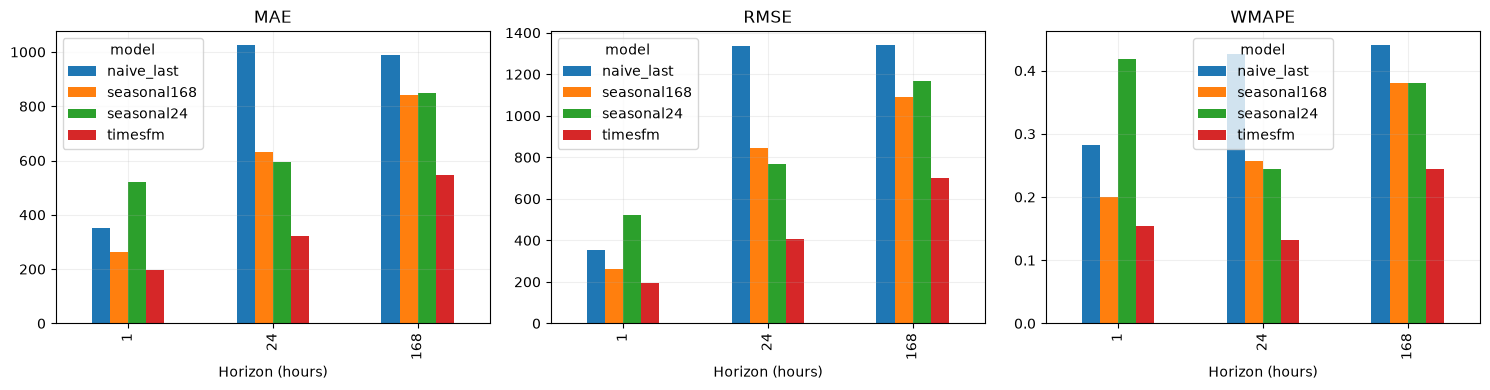

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['mae', 'rmse', 'wmape']):
    pivot_metric = backtest_metrics.pivot(index='horizon_hours', columns='model', values=metric)
    pivot_metric.plot(kind='bar', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Horizon (hours)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6) Forecast Next Week (168 Hours)

Generate point and uncertainty forecasts from the latest available history.


In [11]:
latest_pos = len(arr) - 1
latest_ts = series_df['timestamp'].iloc[latest_pos]

context = arr[-cfg.context_len:]
context_start = series_df['timestamp'].iloc[len(arr) - cfg.context_len]

pred_p50, pred_quant = run_timesfm_forecast(context=context, start_ts=context_start, horizon=cfg.max_horizon)
forecast_index = pd.date_range(latest_ts + pd.Timedelta(hours=1), periods=cfg.max_horizon, freq='h')

forecast_df = pd.DataFrame(
    {
        'timestamp': forecast_index,
        'timesfm_p50_visitors': pred_p50,
        'timesfm_q10_visitors': pred_quant[:, 1],
        'timesfm_q90_visitors': pred_quant[:, 9],
    }
)
forecast_df['uncertainty_band'] = forecast_df['timesfm_q90_visitors'] - forecast_df['timesfm_q10_visitors']

forecast_df.head(12)

,timestamp,timesfm_p50_visitors,timesfm_q10_visitors,timesfm_q90_visitors,uncertainty_band
0,1995-09-01 00:00:00,2157.649170,1662.736816,2690.370361,1027.633545
1,1995-09-01 01:00:00,2020.923096,1493.956299,2638.345459,1144.389160
2,1995-09-01 02:00:00,1782.482910,1193.662476,2459.143555,1265.481079
3,1995-09-01 03:00:00,1633.295410,983.289673,2404.656982,1421.367310
4,1995-09-01 04:00:00,1498.486328,875.030151,2300.103516,1425.073364
5,1995-09-01 05:00:00,1527.699585,882.547607,2374.007080,1491.459473
6,1995-09-01 06:00:00,1892.636475,1188.776489,2822.582031,1633.805542
7,1995-09-01 07:00:00,2773.085205,1991.470825,3829.131836,1837.661011
8,1995-09-01 08:00:00,3697.317871,2851.162842,4790.077148,1938.914307
9,1995-09-01 09:00:00,4433.766602,3520.378418,5606.506836,2086.128418


## 7) Operations Layer: Auto-Scale, Latency, Downtime Risk

We map traffic forecasts into infrastructure decisions.

Assumptions (replace with real platform SRE telemetry):

- One server handles `6000` visitors/hour at acceptable latency.
- Target utilization for safety: `65%`.
- Baseline live servers inferred from recent observed traffic.


In [12]:
# Capacity assumptions
SERVER_CAPACITY_PER_HOUR = 6000.0
TARGET_UTILIZATION = 0.65

# Infer current baseline server count from recent week observed peak traffic.
recent_week_peak = float(series_df['visitors'].tail(168).max())
baseline_servers = max(1, int(np.ceil(recent_week_peak / (SERVER_CAPACITY_PER_HOUR * TARGET_UTILIZATION))))

ops_df = forecast_df.copy()
ops_df['servers_needed_q90'] = np.ceil(
    ops_df['timesfm_q90_visitors'] / (SERVER_CAPACITY_PER_HOUR * TARGET_UTILIZATION)
).astype(int)
ops_df['servers_needed_q90'] = ops_df['servers_needed_q90'].clip(lower=1)

ops_df['autoscale_delta'] = ops_df['servers_needed_q90'] - baseline_servers
ops_df['autoscale_action'] = np.select(
    [ops_df['autoscale_delta'] > 0, ops_df['autoscale_delta'] < 0],
    ['scale_up', 'scale_down'],
    default='hold',
)

# Expected utilization if we follow q90 server sizing.
ops_df['expected_utilization_p50'] = (
    ops_df['timesfm_p50_visitors']
    / (ops_df['servers_needed_q90'] * SERVER_CAPACITY_PER_HOUR + 1e-6)
)

# Simplified latency proxy model (ms): sharply increases at high utilization.
ops_df['estimated_p95_latency_ms'] = 120.0 + 260.0 * np.power(ops_df['expected_utilization_p50'], 2.2)

# Downtime / saturation risk flag using q90 demand and utilization stress.
ops_df['downtime_risk_flag'] = np.select(
    [
        ops_df['expected_utilization_p50'] >= 0.90,
        ops_df['expected_utilization_p50'] >= 0.75,
    ],
    ['high', 'medium'],
    default='low',
)

print('Baseline live servers:', baseline_servers)
ops_df.head(12)

Baseline live servers: 2


,timestamp,timesfm_p50_visitors,timesfm_q10_visitors,timesfm_q90_visitors,uncertainty_band,servers_needed_q90,autoscale_delta,autoscale_action,expected_utilization_p50,estimated_p95_latency_ms,downtime_risk_flag
0,1995-09-01 00:00:00,2157.649170,1662.736816,2690.370361,1027.633545,1,-1,scale_down,0.359608,147.403020,low
1,1995-09-01 01:00:00,2020.923096,1493.956299,2638.345459,1144.389160,1,-1,scale_down,0.336821,143.727399,low
2,1995-09-01 02:00:00,1782.482910,1193.662476,2459.143555,1265.481079,1,-1,scale_down,0.297080,138.000991,low
3,1995-09-01 03:00:00,1633.295410,983.289673,2404.656982,1421.367310,1,-1,scale_down,0.272216,134.851935,low
4,1995-09-01 04:00:00,1498.486328,875.030151,2300.103516,1425.073364,1,-1,scale_down,0.249748,132.287873,low
5,1995-09-01 05:00:00,1527.699585,882.547607,2374.007080,1491.459473,1,-1,scale_down,0.254617,132.821065,low
6,1995-09-01 06:00:00,1892.636475,1188.776489,2822.582031,1633.805542,1,-1,scale_down,0.315439,140.539433,low
7,1995-09-01 07:00:00,2773.085205,1991.470825,3829.131836,1837.661011,1,-1,scale_down,0.462181,167.594818,low
8,1995-09-01 08:00:00,3697.317871,2851.162842,4790.077148,1938.914307,2,0,hold,0.308110,139.504083,low
9,1995-09-01 09:00:00,4433.766602,3520.378418,5606.506836,2086.128418,2,0,hold,0.369481,149.085386,low


In [13]:
# Horizon KPI summary for SRE / Infra planning
kpi_summary = pd.DataFrame(
    {
        'metric': [
            'forecast_horizon_hours',
            'avg_p50_traffic_per_hour',
            'avg_q90_traffic_per_hour',
            'max_q90_traffic_per_hour',
            'baseline_servers',
            'avg_servers_needed_q90',
            'max_servers_needed_q90',
            'scale_up_hours',
            'high_risk_hours',
            'avg_estimated_p95_latency_ms',
            'max_estimated_p95_latency_ms',
        ],
        'value': [
            len(ops_df),
            float(ops_df['timesfm_p50_visitors'].mean()),
            float(ops_df['timesfm_q90_visitors'].mean()),
            float(ops_df['timesfm_q90_visitors'].max()),
            float(baseline_servers),
            float(ops_df['servers_needed_q90'].mean()),
            float(ops_df['servers_needed_q90'].max()),
            int((ops_df['autoscale_action'] == 'scale_up').sum()),
            int((ops_df['downtime_risk_flag'] == 'high').sum()),
            float(ops_df['estimated_p95_latency_ms'].mean()),
            float(ops_df['estimated_p95_latency_ms'].max()),
        ],
    }
)

kpi_summary

,metric,value
0,forecast_horizon_hours,168.000000
1,avg_p50_traffic_per_hour,2466.995605
2,avg_q90_traffic_per_hour,3320.543213
3,max_q90_traffic_per_hour,6205.610840
4,baseline_servers,2.000000
5,avg_servers_needed_q90,1.273810
6,max_servers_needed_q90,2.000000
7,scale_up_hours,0.000000
8,high_risk_hours,0.000000
9,avg_estimated_p95_latency_ms,142.352420


## 8) Save Deliverables

Outputs:

- `backtest_metrics.csv`
- `backtest_detail.csv`
- `forecast_next_168_hours.csv`
- `autoscaling_plan.csv`
- `infra_kpi_summary.csv`


In [14]:
backtest_metrics_path = ART_DIR / 'backtest_metrics.csv'
backtest_detail_path = ART_DIR / 'backtest_detail.csv'
forecast_path = ART_DIR / 'forecast_next_168_hours.csv'
autoscaling_path = ART_DIR / 'autoscaling_plan.csv'
kpi_path = ART_DIR / 'infra_kpi_summary.csv'

backtest_metrics.to_csv(backtest_metrics_path, index=False)
backtest_detail.to_csv(backtest_detail_path, index=False)
forecast_df.to_csv(forecast_path, index=False)
ops_df.to_csv(autoscaling_path, index=False)
kpi_summary.to_csv(kpi_path, index=False)

print('Saved artifacts:')
for p in [
    backtest_metrics_path,
    backtest_detail_path,
    forecast_path,
    autoscaling_path,
    kpi_path,
]:
    print('-', p)

backtest_metrics

Saved artifacts:
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm/backtest_metrics.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm/backtest_detail.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm/forecast_next_168_hours.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm/autoscaling_plan.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/website_traffic_timesfm/infra_kpi_summary.csv


,horizon_hours,model,mae,rmse,wmape
3,1,timesfm,195.057129,195.057130,0.154026
1,1,seasonal168,262.666667,262.666667,0.200074
0,1,naive_last,353.000000,353.000000,0.282468
2,1,seasonal24,521.000000,521.000000,0.418227
7,24,timesfm,320.556091,406.424327,0.131776
6,24,seasonal24,594.833333,767.471893,0.243626
5,24,seasonal168,630.152796,846.554583,0.257414
4,24,naive_last,1025.972229,1338.271680,0.426754
11,168,timesfm,547.298604,701.211755,0.244770
9,168,seasonal168,839.843262,1092.464596,0.380091


## Assumptions, Limitations, and Production Next Steps

### Assumptions

- `count` is used as website traffic proxy (requests/visitors per minute).
- Server capacity and latency model are simplified and constant.

### Limitations

- No exogenous drivers (marketing events, launches, incidents, region effects).
- Single aggregate traffic series; no service-level decomposition.

### Production next steps

- Add real telemetry covariates (deploys, campaigns, incident tags, cache hit rate).
- Forecast per service/region and reconcile globally.
- Couple forecast with autoscaling controller policies and cost constraints.
- Track post-decision KPIs: latency SLO breach %, error rates, scaling cost.
